In [47]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
conn = sqlite3.connect("alzheimers.db")
oasis1 = pd.read_csv("oasis1_snapshot.csv")
oasis2 = pd.read_csv("oasis2_longitudinal.csv")

In [28]:
oasis1.to_sql("oasis1", conn, if_exists='replace',index = False)
oasis2.to_sql("oasis2", conn, if_exists='replace',index = False)


373

In [29]:
print(pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn))

     name
0  oasis1
1  oasis2


In [30]:
#queries 
query = """
SELECT "group", 
       COUNT(*) AS total_patients, 
       ROUND(AVG(nwbv), 4) AS avg_brain_volume, 
       ROUND(AVG(mmse), 1) AS avg_mmse, 
       ROUND(AVG(age), 1) AS avg_age
FROM oasis1
GROUP BY "group"
ORDER BY avg_brain_volume;       
"""

q1 = pd.read_sql_query(query,conn)
print("\n brain volume by group: ")
print(q1.to_string(index=False))


 brain volume by group: 
      group  total_patients  avg_brain_volume  avg_mmse  avg_age
   Demented             100            0.7220      24.3     76.8
Nondemented              98            0.7525      29.0     75.9


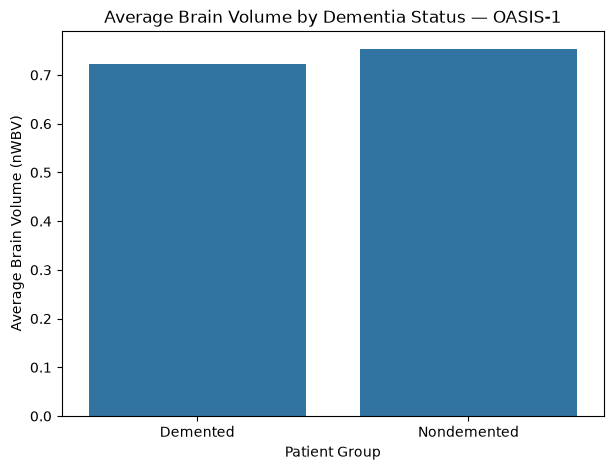

In [48]:
# chart 1 — brain volume by group
plt.figure(figsize=(7, 5))
sns.barplot(
    data=q1,
    x="group",
    y="avg_brain_volume",
    errorbar=None)
plt.title("Average Brain Volume by Dementia Status — OASIS-1")
plt.xlabel("Patient Group")
plt.ylabel("Average Brain Volume (nWBV)")
plt.show()

In [32]:
query = """
SELECT "group", 
        ROUND(AVG(nwbv),4) AS avg_brain_volume, 
        ROUND(AVG(mmse),4) AS avg_mmse
FROM oasis1
GROUP BY "group"
ORDER BY avg_mmse;
"""
q2 = pd.read_sql_query(query,conn)
print("\n mmse and brain volume by group")
print(q2.to_string(index=False))


 mmse and brain volume by group
      group  avg_brain_volume  avg_mmse
   Demented            0.7220   24.3200
Nondemented            0.7525   28.9592


In [33]:
query = """
SELECT "group",
       ROUND(AVG(age),1) AS avg_age,
       MAX(age) AS maximum_age,
       MIN(age) AS minimum_age
FROM oasis1
GROUP BY "group";       
"""
q3 = pd.read_sql_query(query,conn)
print("\n age by group")
print(q3.to_string(index=False))


 age by group
      group  avg_age  maximum_age  minimum_age
   Demented     76.8           96           62
Nondemented     75.9           94           60


In [34]:
query = """
SELECT COUNT(*) AS total_patients,
       ROUND(AVG(nwbv), 4) AS avg_brain_volume, 
CASE
    WHEN education <= 2 THEN 'Low'
    WHEN education <= 4 THEN 'Medium'
    WHEN education > 4 THEN 'High'
END AS education_level
FROM oasis1
WHERE "group" = "Demented"
GROUP BY education_level
ORDER BY avg_brain_volume DESC;               
"""
q4 = pd.read_sql_query(query,conn)
print("\n education vs brain volume in demented patients")
print(q4.to_string(index=False))


 education vs brain volume in demented patients
 total_patients  avg_brain_volume education_level
             36            0.7250          Medium
             14            0.7210            High
             50            0.7201             Low


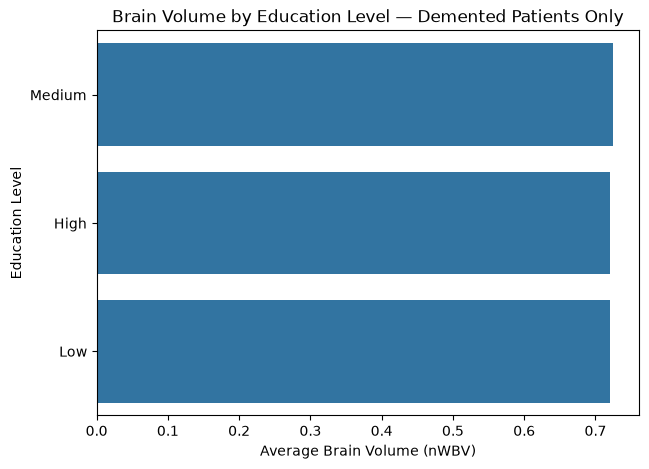

In [49]:
# chart 2 — education vs brain volume
plt.figure(figsize=(7, 5))
sns.barplot(
    data=q4,
    x="avg_brain_volume",
    y="education_level",
    errorbar=None)
plt.title("Brain Volume by Education Level — Demented Patients Only")
plt.xlabel("Average Brain Volume (nWBV)")
plt.ylabel("Education Level")
plt.show()

In [36]:
query = """
SELECT gender,
       "group",
       COUNT(*) AS total_patients,
       ROUND(AVG(nwbv), 4) AS avg_brain_volume
FROM oasis1
GROUP BY gender,"group"
ORDER BY "group", gender
""" 
q5 = pd.read_sql_query(query,conn)
print("\n gender by group:")
print(q5.to_string(index=False))


 gender by group:
gender       group  total_patients  avg_brain_volume
     F    Demented              59            0.7226
     M    Demented              41            0.7211
     F Nondemented              72            0.7564
     M Nondemented              26            0.7417


In [37]:
#quering oasis 2
query = """
SELECT "group",
        visit,
        COUNT(DISTINCT patient_id) AS patient_count,
        ROUND(AVG(nwbv), 4) AS avg_brain_volume,
        ROUND(AVG(mmse), 1) AS avg_mmse
FROM oasis2
GROUP BY "group", visit
ORDER BY "group", visit        
"""

q6 = pd.read_sql_query(query,conn)
print("\n brain volume over visits by group: ")
print(q6.to_string(index=False))


 brain volume over visits by group: 
      group  visit  patient_count  avg_brain_volume  avg_mmse
  Converted      1             14            0.7379      29.4
  Converted      2             12            0.7282      28.0
  Converted      3              8            0.7062      28.5
  Converted      4              2            0.6950      28.0
  Converted      5              1            0.6694      30.0
   Demented      1             64            0.7244      25.3
   Demented      2             62            0.7135      24.2
   Demented      3             16            0.7007      24.3
   Demented      4              3            0.6991      20.0
   Demented      5              1            0.6761       4.0
Nondemented      1             72            0.7461      29.2
Nondemented      2             70            0.7377      29.1
Nondemented      3             34            0.7356      29.5
Nondemented      4             10            0.7389      29.6
Nondemented      5              

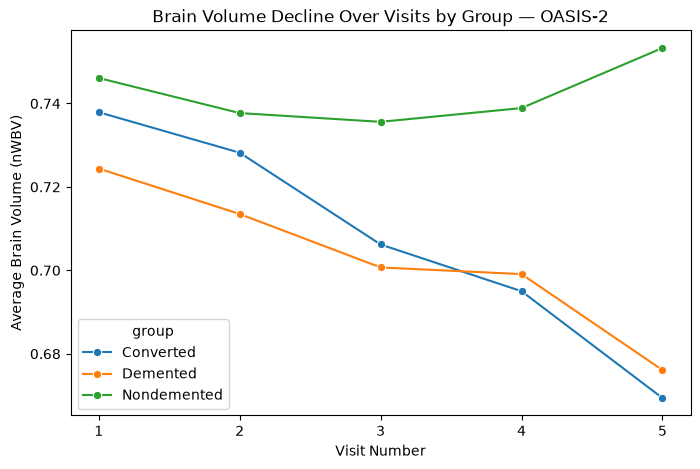

In [50]:
# chart 3 — brain volume over visit by group
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=q6,
    x="visit",
    y="avg_brain_volume",
    hue="group",
    marker="o")
plt.title("Brain Volume Decline Over Visits by Group — OASIS-2")
plt.xlabel("Visit Number")
plt.ylabel("Average Brain Volume (nWBV)")
plt.xticks(q6["visit"].unique())
plt.show()

In [39]:
query = """
SELECT "group",
        visit,
        ROUND(AVG(nwbv), 4) AS avg_brain_volume,
        ROUND(AVG(mmse), 1) AS avg_mmse
FROM oasis2 
WHERE "group" = 'Converted' OR "group" = 'Nondemented'
GROUP BY "group", visit
ORDER BY "group", visit ;      
"""
q7 = pd.read_sql_query(query, conn)
print("\n Converted vs Nondemented progression: ")
print(q7.to_string(index=False))


 Converted vs Nondemented progression: 
      group  visit  avg_brain_volume  avg_mmse
  Converted      1            0.7379      29.4
  Converted      2            0.7282      28.0
  Converted      3            0.7062      28.5
  Converted      4            0.6950      28.0
  Converted      5            0.6694      30.0
Nondemented      1            0.7461      29.2
Nondemented      2            0.7377      29.1
Nondemented      3            0.7356      29.5
Nondemented      4            0.7389      29.6
Nondemented      5            0.7533      28.8


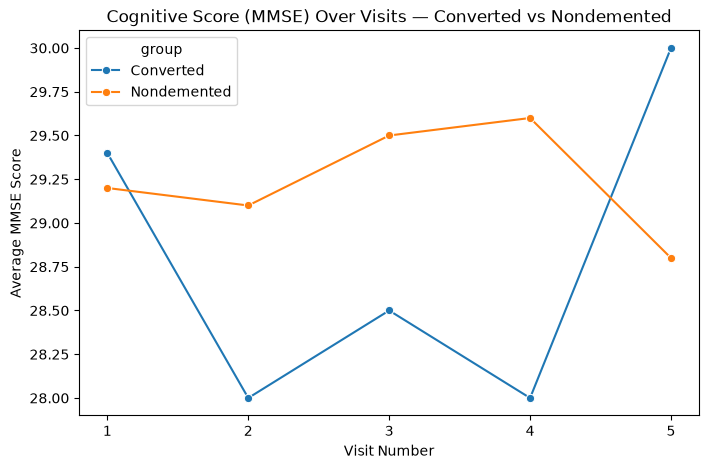

In [51]:
# chart 4 — mmse over visits converted vs nondemented
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=q7,
    x="visit",
    y="avg_mmse",
    hue="group",
    marker="o")
plt.title("Cognitive Score (MMSE) Over Visits — Converted vs Nondemented")
plt.xlabel("Visit Number")
plt.ylabel("Average MMSE Score")
plt.xticks(q7["visit"].unique())
plt.show()

In [41]:
query = """
SELECT "group",
       COUNT(DISTINCT patient_id) AS patient_count,
       ROUND(AVG(starting_volume), 4) AS avg_starting_volume,
       ROUND(AVG(final_volume), 4) AS avg_final_volume,
       ROUND(AVG(total_decline), 4) AS avg_total_decline
FROM ( SELECT patient_id, 
       "group",
       MAX(nwbv) AS starting_volume,
       MIN(nwbv) AS final_volume,
       MAX(nwbv) - MIN(nwbv) AS total_decline
FROM oasis2
GROUP BY patient_id, "group") AS patient_summary 
GROUP BY "group"
ORDER BY AVG_total_decline DESC;
"""
q8 = pd.read_sql_query(query, conn)
print("\n total brain volume decline by group: ")
print(q8.to_string(index=False))


 total brain volume decline by group: 
      group  patient_count  avg_starting_volume  avg_final_volume  avg_total_decline
  Converted             14               0.7385            0.7147             0.0237
   Demented             64               0.7253            0.7100             0.0153
Nondemented             72               0.7474            0.7330             0.0143


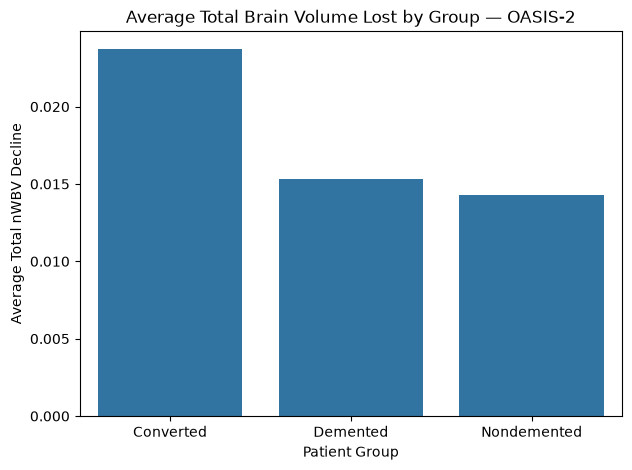

In [52]:
# chart 5 — average total decline per group
plt.figure(figsize=(7, 5))
sns.barplot(
    data=q8,
    x="group",
    y="avg_total_decline",
    errorbar=None)
plt.title("Average Total Brain Volume Lost by Group — OASIS-2")
plt.xlabel("Patient Group")
plt.ylabel("Average Total nWBV Decline")
plt.show()

In [43]:
query = """
SELECT visit,
       COUNT(patient_id) AS patient_count,
       ROUND(AVG(age), 1) AS avg_age
FROM oasis2
WHERE "group" = 'Converted' AND cdr = 0.5
GROUP BY visit
ORDER BY visit;       
"""
q9 = pd.read_sql_query(query, conn)
print("\n conversion visit: ")
print(q9.to_string(index=False))



 conversion visit: 
 visit  patient_count  avg_age
     1              1     65.0
     2              8     78.9
     3              7     82.3
     4              2     88.0
     5              1     86.0


In [44]:
query = """
SELECT patient_id,
       visit,
       mr_delay,
       age,
       cdr,
       mmse,
       ROUND(nwbv, 4) AS brain_volume
FROM oasis2
WHERE "group" = 'Converted'
ORDER BY patient_id, visit ;      
"""

q10= pd.read_sql_query(query, conn)
print("\n Converted patients visit by visit: ")
print(q10.to_string(index=False))


 Converted patients visit by visit: 
patient_id  visit  mr_delay  age  cdr  mmse  brain_volume
 OAS2_0018      1         0   87  0.0  30.0        0.7151
 OAS2_0018      3       489   88  0.0  29.0        0.7134
 OAS2_0018      4      1933   92  0.5  27.0        0.6958
 OAS2_0020      1         0   80  0.0  29.0        0.6932
 OAS2_0020      2       756   82  0.5  28.0        0.6766
 OAS2_0020      3      1563   84  0.5  26.0        0.6664
 OAS2_0031      1         0   86  0.0  30.0        0.7181
 OAS2_0031      2       446   88  0.0  30.0        0.7195
 OAS2_0031      3      1588   91  0.5  28.0        0.6955
 OAS2_0041      1         0   71  0.0  27.0        0.7713
 OAS2_0041      2       756   73  0.0  28.0        0.7677
 OAS2_0041      3      1331   75  0.5  28.0        0.7603
 OAS2_0054      1         0   85  0.0  29.0        0.7010
 OAS2_0054      2       846   87  0.5  24.0        0.6827
 OAS2_0092      1         0   83  0.0  28.0        0.7477
 OAS2_0092      2       706   84  

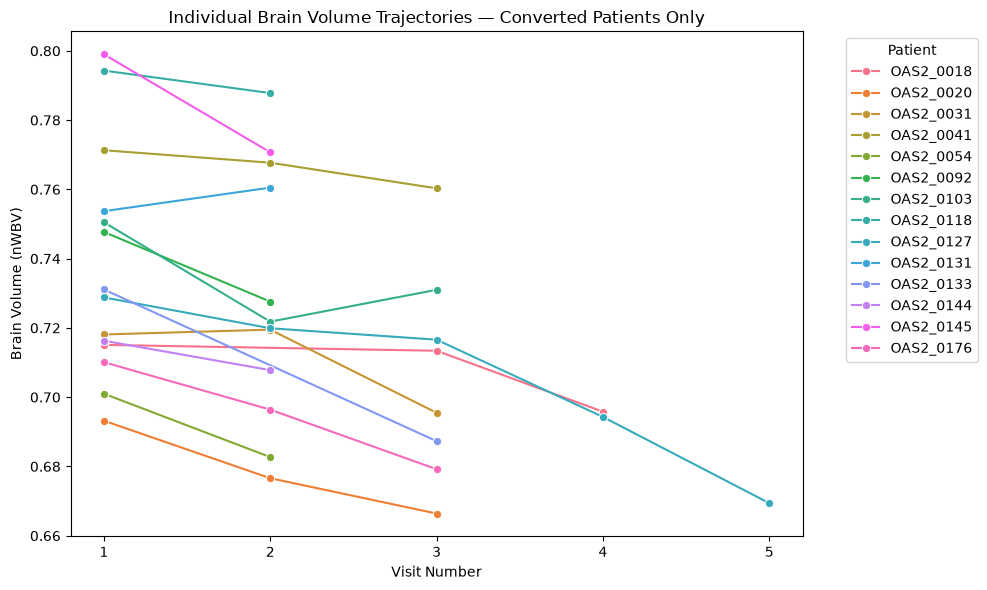

In [53]:
# chart 6 — individual converted patient brain volume trajectories
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=q10,
    x="visit",
    y="brain_volume",
    hue="patient_id",
    marker="o")
plt.title("Individual Brain Volume Trajectories — Converted Patients Only")
plt.xlabel("Visit Number")
plt.ylabel("Brain Volume (nWBV)")
plt.xticks(q10["visit"].unique())
plt.legend(
    title="Patient",
    bbox_to_anchor=(1.05, 1),
    loc="upper left")
plt.tight_layout()
plt.show()

In [46]:
conn.close()
print("connection closed")

connection closed
